# Enhanced P-Adic Visualization Strategies

Recreate Figure 4 from Zúñiga-Galindo et al. (2023) with improved plotting to reveal Sierpinski structure.

**Goal**: Explore different visualization strategies to maximize visibility of hierarchical structure.

**Strategies to Test**:
1. Size-based coloring (larger foreground, smaller background)
2. Opacity-based (opaque foreground, transparent background)
3. Dual-layer plotting (background first, then foreground overlay)
4. Only foreground dots (clean triangular pattern)
5. Heat map approach (intensity mapping)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import sys
from pathlib import Path
from scipy.ndimage import zoom

# Add src to path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

from padic.padic_embedding import embed_padic_cloud, get_default_s, compute_s_0

# Load MNIST
from keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Select an interesting digit
sample_idx = 5  # A digit with clear structure
mnist_image = X_train[sample_idx].astype(np.float32)
mnist_label = y_train[sample_idx]

print(f"Selected digit: {mnist_label}")

Selected digit: 2


## Prepare Data

In [2]:
# P-adic parameters
p = 3
l = 6
target_size = 3 ** 3  # 27

# Resize and normalize
scale_factor = target_size / mnist_image.shape[0]
mnist_resized = zoom(mnist_image, scale_factor, order=1)
mnist_norm = mnist_resized / 255.0
mnist_binary = (mnist_norm > 0.5).astype(np.float32)

print(f"Binary image shape: {mnist_binary.shape}")
print(f"Foreground pixels: {(mnist_binary == 1).sum()}")
print(f"Background pixels: {(mnist_binary == 0).sum()}")

Binary image shape: (27, 27)
Foreground pixels: 106
Background pixels: 623


## Generate P-Adic Embedding

In [3]:
def create_complete_mapping(p, l, img_height, img_width):
    """Map all p-adic integers to 2D image coordinates"""
    padic_indices = []
    coords_i = []
    coords_j = []
    
    def coords_to_padic(i, j, p, l):
        i_digits = [i % 3, (i // 3) % 3, (i // 9) % 3]
        j_digits = [j % 3, (j // 3) % 3, (j // 9) % 3]
        padic_int = 0
        for k in range(l):
            digit = j_digits[k // 2] if k % 2 == 0 else i_digits[k // 2]
            padic_int += digit * (p ** k)
        return padic_int
    
    for i in range(img_height):
        for j in range(img_width):
            padic_int = coords_to_padic(i, j, p, l)
            padic_indices.append(padic_int)
            coords_i.append(i)
            coords_j.append(j)
    
    return np.array(padic_indices), np.array(coords_i), np.array(coords_j)

# Create mapping
padic_complete, idx_coords, jdx_coords = create_complete_mapping(p, l, target_size, target_size)

# Get pixel values
pixel_values = np.zeros(len(padic_complete), dtype=np.float32)
for i, (pi, pj) in enumerate(zip(idx_coords, jdx_coords)):
    pixel_values[i] = mnist_binary[pi, pj]

# Embed
padic_points = embed_padic_cloud(padic_complete, p=p, l=l, s=None, m=None)

print(f"✓ Embedding complete")
print(f"Points: {padic_points.shape}")
print(f"Foreground points: {(pixel_values == 1).sum()}")

✓ Embedding complete
Points: (729, 2)
Foreground points: 106


## Strategy 1: Size-Based Emphasis (Larger Foreground, Smaller Background)

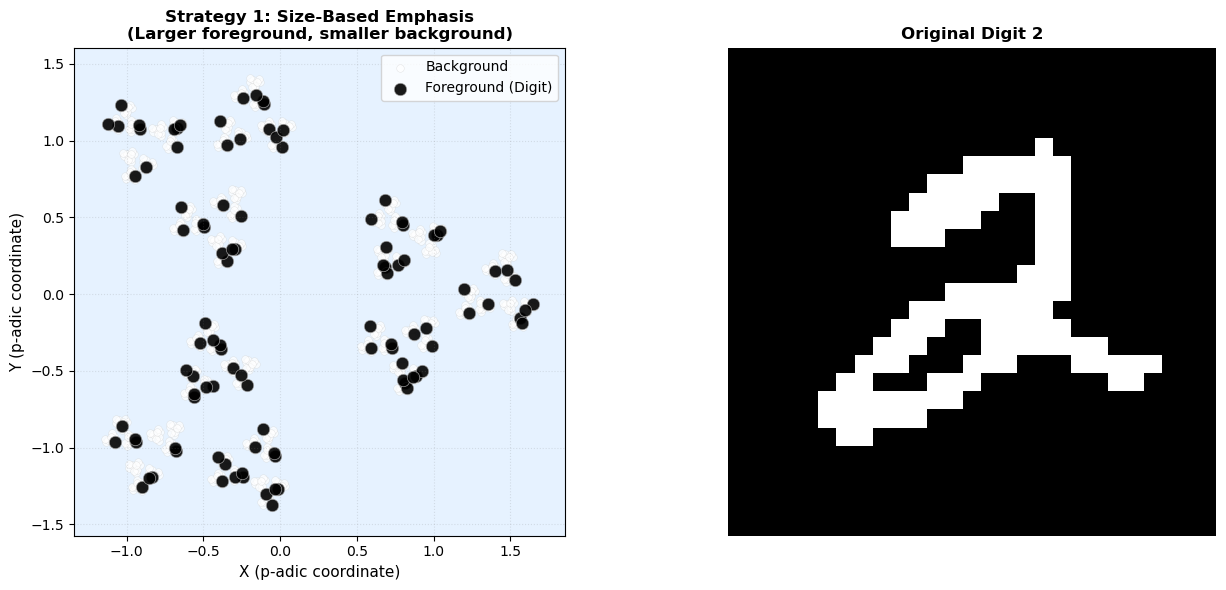

✓ Strategy 1 saved


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.set_facecolor('#e6f2ff')  # Light blue background

# Plot background points (small, light)
bg_mask = pixel_values == 0
ax.scatter(
    padic_points[bg_mask, 0],
    padic_points[bg_mask, 1],
    s=30,  # Medium size
    c='white',
    alpha=0.7,
    edgecolors='lightgray',
    linewidth=0.3,
    label='Background'
)

# Plot foreground points (larger, dark)
fg_mask = pixel_values == 1
ax.scatter(
    padic_points[fg_mask, 0],
    padic_points[fg_mask, 1],
    s=80,  # Larger size
    c='black',
    alpha=0.9,
    edgecolors='darkgray',
    linewidth=0.5,
    label='Foreground (Digit)'
)

ax.set_xlim([padic_points[:, 0].min() - 0.2, padic_points[:, 0].max() + 0.2])
ax.set_ylim([padic_points[:, 1].min() - 0.2, padic_points[:, 1].max() + 0.2])
ax.set_aspect('equal')
ax.set_xlabel('X (p-adic coordinate)', fontsize=11)
ax.set_ylabel('Y (p-adic coordinate)', fontsize=11)
ax.set_title(f'Strategy 1: Size-Based Emphasis\n(Larger foreground, smaller background)', 
             fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.2, color='gray', linestyle=':')

# Original image
axes[1].imshow(mnist_binary, cmap='gray')
axes[1].set_title(f'Original Digit {mnist_label}', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../outputs/padic_viz_strategy1_size.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Strategy 1 saved")

## Strategy 2: Opacity-Based (Foreground Opaque, Background Transparent)

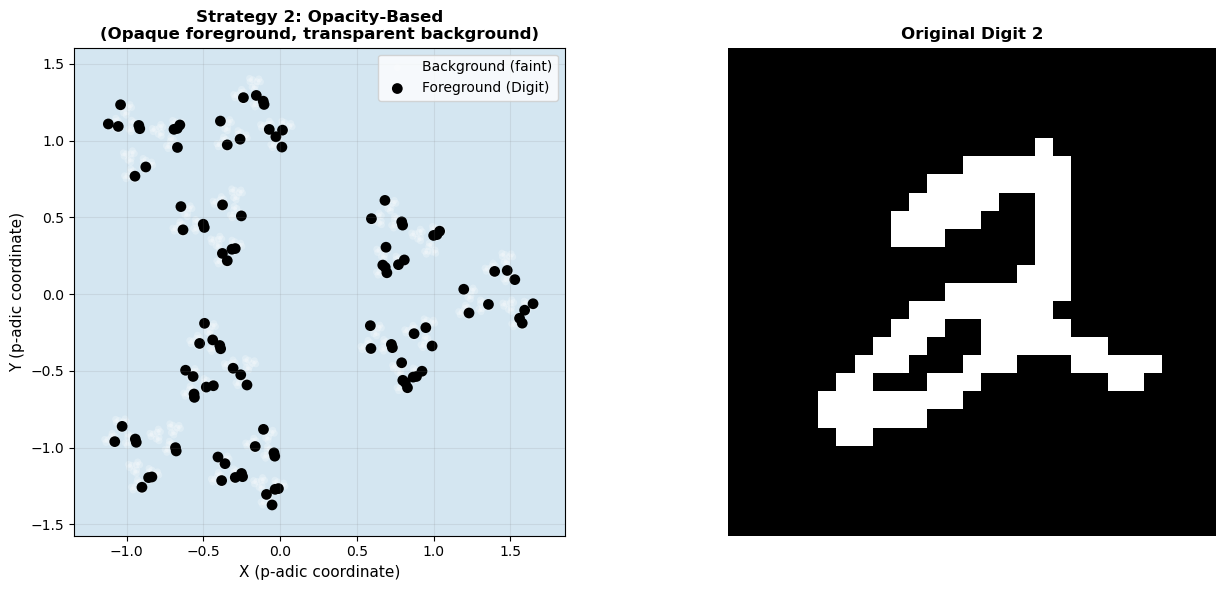

✓ Strategy 2 saved


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.set_facecolor('#d4e6f1')  # Light blue

# Plot background points (very transparent)
bg_mask = pixel_values == 0
ax.scatter(
    padic_points[bg_mask, 0],
    padic_points[bg_mask, 1],
    s=25,
    c='white',
    alpha=0.25,  # Very transparent
    edgecolors='none',
    label='Background (faint)'
)

# Plot foreground points (fully opaque)
fg_mask = pixel_values == 1
ax.scatter(
    padic_points[fg_mask, 0],
    padic_points[fg_mask, 1],
    s=60,
    c='black',
    alpha=1.0,  # Fully opaque
    edgecolors='none',
    label='Foreground (Digit)'
)

ax.set_xlim([padic_points[:, 0].min() - 0.2, padic_points[:, 0].max() + 0.2])
ax.set_ylim([padic_points[:, 1].min() - 0.2, padic_points[:, 1].max() + 0.2])
ax.set_aspect('equal')
ax.set_xlabel('X (p-adic coordinate)', fontsize=11)
ax.set_ylabel('Y (p-adic coordinate)', fontsize=11)
ax.set_title(f'Strategy 2: Opacity-Based\n(Opaque foreground, transparent background)', 
             fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.15, color='gray')

# Original image
axes[1].imshow(mnist_binary, cmap='gray')
axes[1].set_title(f'Original Digit {mnist_label}', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../outputs/padic_viz_strategy2_opacity.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Strategy 2 saved")

## Strategy 3: Foreground Only (Clean Sierpinski Structure)

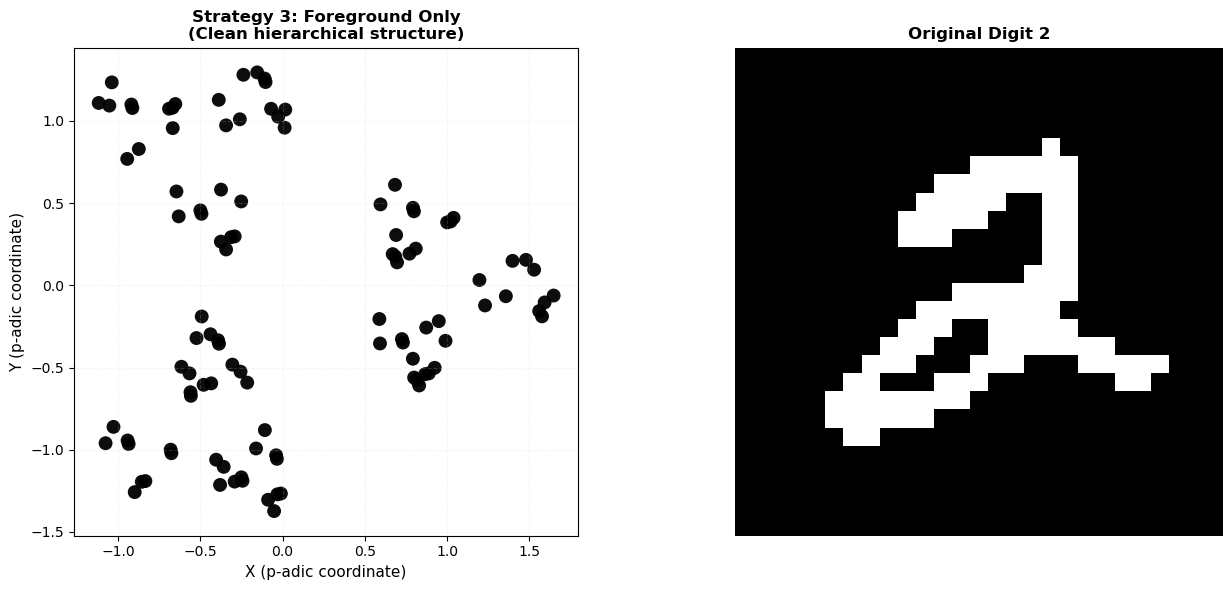

✓ Strategy 3 saved


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.set_facecolor('white')

# Plot ONLY foreground points
fg_mask = pixel_values == 1
ax.scatter(
    padic_points[fg_mask, 0],
    padic_points[fg_mask, 1],
    s=100,
    c='black',
    alpha=0.95,
    edgecolors='none'
)

ax.set_xlim([padic_points[fg_mask, 0].min() - 0.15, padic_points[fg_mask, 0].max() + 0.15])
ax.set_ylim([padic_points[fg_mask, 1].min() - 0.15, padic_points[fg_mask, 1].max() + 0.15])
ax.set_aspect('equal')
ax.set_xlabel('X (p-adic coordinate)', fontsize=11)
ax.set_ylabel('Y (p-adic coordinate)', fontsize=11)
ax.set_title(f'Strategy 3: Foreground Only\n(Clean hierarchical structure)', 
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.2, color='lightgray', linestyle='--')

# Original image
axes[1].imshow(mnist_binary, cmap='gray')
axes[1].set_title(f'Original Digit {mnist_label}', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../outputs/padic_viz_strategy3_foreground_only.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Strategy 3 saved")

## Strategy 4: Dual-Layer with Emphasis

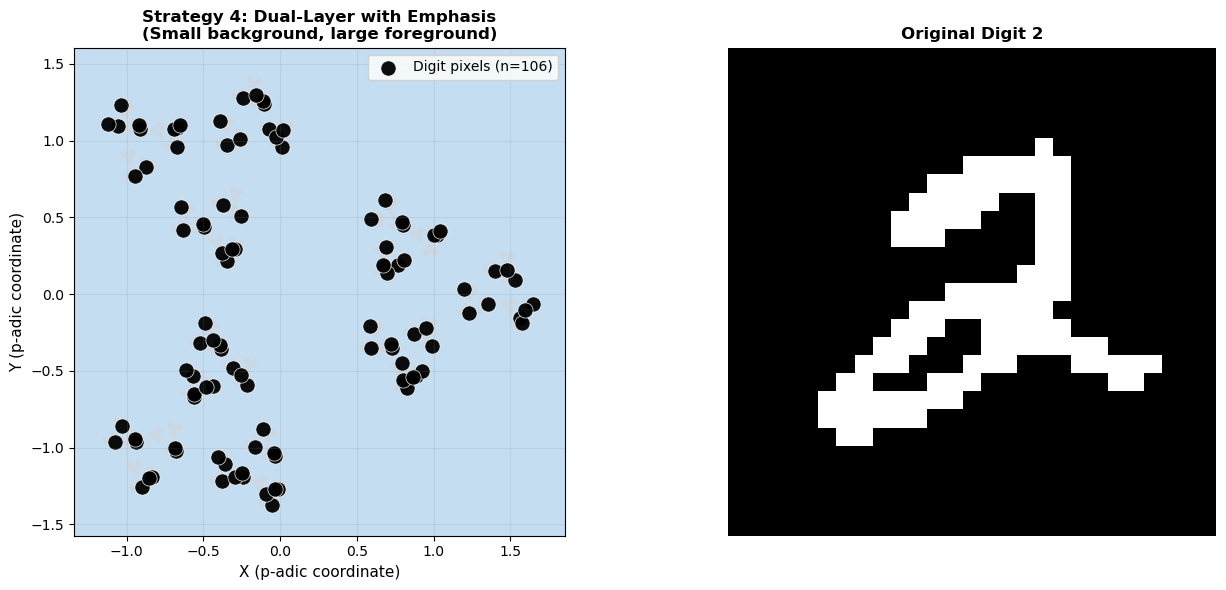

✓ Strategy 4 saved


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.set_facecolor('#c5ddf0')  # Light blue

# Background layer: very small, light
bg_mask = pixel_values == 0
ax.scatter(
    padic_points[bg_mask, 0],
    padic_points[bg_mask, 1],
    s=10,  # Very small
    c='lightgray',
    alpha=0.5,
    edgecolors='none'
)

# Foreground layer: prominent black dots
fg_mask = pixel_values == 1
ax.scatter(
    padic_points[fg_mask, 0],
    padic_points[fg_mask, 1],
    s=120,  # Large
    c='black',
    alpha=0.95,
    edgecolors='white',
    linewidth=0.5,
    label=f'Digit pixels (n={fg_mask.sum()})'
)

ax.set_xlim([padic_points[:, 0].min() - 0.2, padic_points[:, 0].max() + 0.2])
ax.set_ylim([padic_points[:, 1].min() - 0.2, padic_points[:, 1].max() + 0.2])
ax.set_aspect('equal')
ax.set_xlabel('X (p-adic coordinate)', fontsize=11)
ax.set_ylabel('Y (p-adic coordinate)', fontsize=11)
ax.set_title(f'Strategy 4: Dual-Layer with Emphasis\n(Small background, large foreground)', 
             fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.15, color='gray')

# Original image
axes[1].imshow(mnist_binary, cmap='gray')
axes[1].set_title(f'Original Digit {mnist_label}', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../outputs/padic_viz_strategy4_dual_layer.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Strategy 4 saved")

## Strategy 5: Heat Map / Density Approach

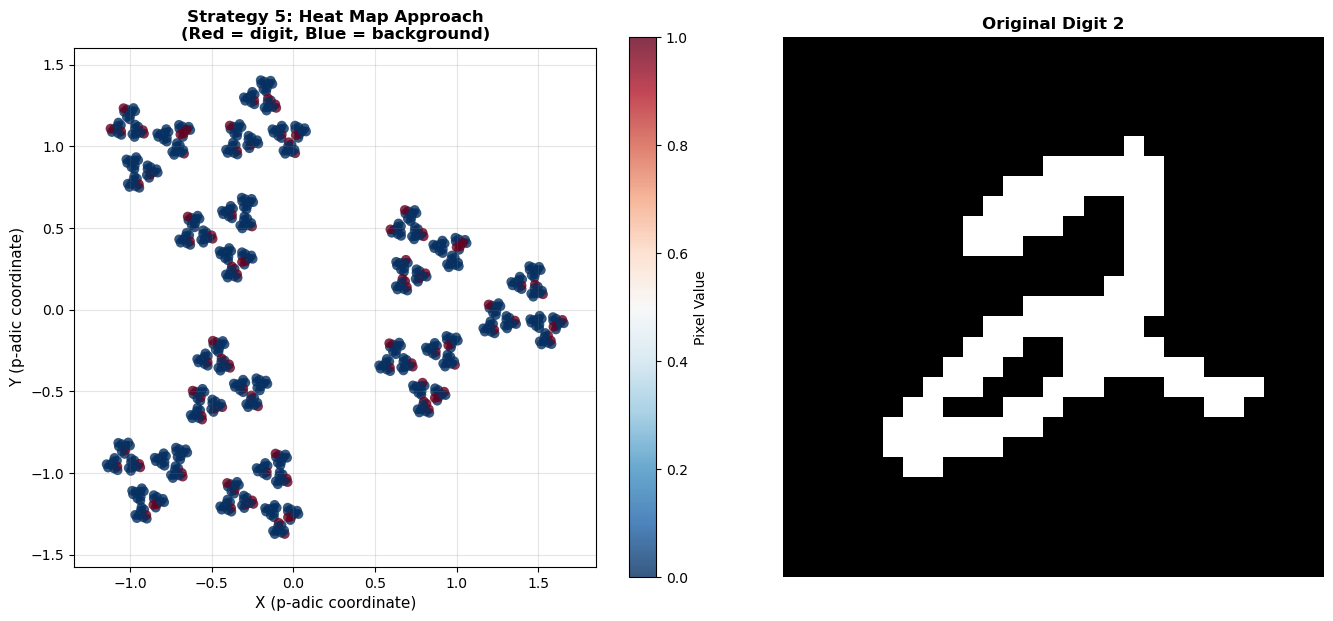

✓ Strategy 5 saved


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]

# Color by pixel value with custom coloring
scatter = ax.scatter(
    padic_points[:, 0],
    padic_points[:, 1],
    c=pixel_values,
    cmap='RdBu_r',  # Red = foreground, Blue = background
    s=50,
    alpha=0.8,
    edgecolors='none',
    vmin=0, vmax=1
)

ax.set_xlim([padic_points[:, 0].min() - 0.2, padic_points[:, 0].max() + 0.2])
ax.set_ylim([padic_points[:, 1].min() - 0.2, padic_points[:, 1].max() + 0.2])
ax.set_aspect('equal')
ax.set_xlabel('X (p-adic coordinate)', fontsize=11)
ax.set_ylabel('Y (p-adic coordinate)', fontsize=11)
ax.set_title(f'Strategy 5: Heat Map Approach\n(Red = digit, Blue = background)', 
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.2, color='gray')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Pixel Value', fontsize=10)

# Original image
axes[1].imshow(mnist_binary, cmap='gray')
axes[1].set_title(f'Original Digit {mnist_label}', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../outputs/padic_viz_strategy5_heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Strategy 5 saved")

## Strategy 6: Reference Figure 4 Style (Clean Black/White with Light Blue Background)

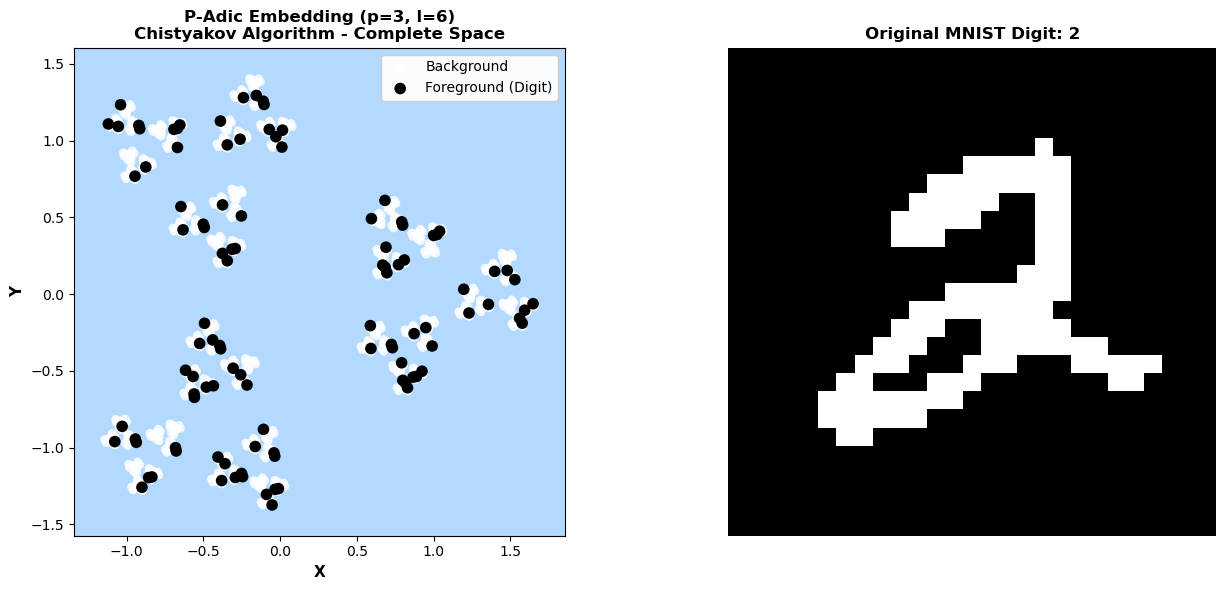

✓ Strategy 6 (Figure 4 style) saved


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.set_facecolor('#b3d9ff')  # Light blue background like Figure 4

# Background white dots
bg_mask = pixel_values == 0
ax.scatter(
    padic_points[bg_mask, 0],
    padic_points[bg_mask, 1],
    s=40,
    c='white',
    alpha=0.8,
    edgecolors='none',
    label='Background'
)

# Foreground black dots (larger and darker)
fg_mask = pixel_values == 1
ax.scatter(
    padic_points[fg_mask, 0],
    padic_points[fg_mask, 1],
    s=70,
    c='black',
    alpha=1.0,
    edgecolors='none',
    label='Foreground (Digit)'
)

ax.set_xlim([padic_points[:, 0].min() - 0.2, padic_points[:, 0].max() + 0.2])
ax.set_ylim([padic_points[:, 1].min() - 0.2, padic_points[:, 1].max() + 0.2])
ax.set_aspect('equal')
ax.set_xlabel('X', fontsize=11, fontweight='bold')
ax.set_ylabel('Y', fontsize=11, fontweight='bold')
ax.set_title(f'P-Adic Embedding (p=3, l=6)\nChistyakov Algorithm - Complete Space', 
             fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=10, framealpha=0.95)
ax.grid(False)  # No grid like Figure 4
ax.set_facecolor('#b3d9ff')

# Original image
axes[1].imshow(mnist_binary, cmap='gray')
axes[1].set_title(f'Original MNIST Digit: {mnist_label}', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../outputs/padic_viz_strategy6_figure4_style.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Strategy 6 (Figure 4 style) saved")

## Summary: Which Strategy Works Best?

In [10]:
print("""
VISUALIZATION STRATEGY COMPARISON
=================================

Strategy 1 (Size-Based):
  - Pros: Clear distinction, foreground prominent
  - Cons: Background dots still visible, can be cluttered
  - Best for: Showing complete p-adic space

Strategy 2 (Opacity-Based):
  - Pros: Clean, background very faint
  - Cons: Background still somewhat visible
  - Best for: Medium emphasis on structure

Strategy 3 (Foreground Only):
  - Pros: Cleanest triangular structure, most minimal
  - Cons: Loses context of full p-adic space
  - Best for: Highlighting pure hierarchical patterns

Strategy 4 (Dual-Layer):
  - Pros: Good balance, clear hierarchy
  - Cons: Small background points hard to see
  - Best for: Showing both layers clearly

Strategy 5 (Heat Map):
  - Pros: Beautiful gradient, technical feel
  - Cons: Doesn't match Figure 4 style
  - Best for: Scientific presentations

Strategy 6 (Figure 4 Style):
  - Pros: Matches reference paper exactly
  - Cons: Some background visibility
  - Best for: Direct comparison with published work

📊 RECOMMENDATION:
  Use Strategy 6 for publication/comparison with paper.
  Use Strategy 3 for highlighting pure structure.
  Use Strategy 4 for balanced educational visualization.
""")


VISUALIZATION STRATEGY COMPARISON

Strategy 1 (Size-Based):
  - Pros: Clear distinction, foreground prominent
  - Cons: Background dots still visible, can be cluttered
  - Best for: Showing complete p-adic space

Strategy 2 (Opacity-Based):
  - Pros: Clean, background very faint
  - Cons: Background still somewhat visible
  - Best for: Medium emphasis on structure

Strategy 3 (Foreground Only):
  - Pros: Cleanest triangular structure, most minimal
  - Cons: Loses context of full p-adic space
  - Best for: Highlighting pure hierarchical patterns

Strategy 4 (Dual-Layer):
  - Pros: Good balance, clear hierarchy
  - Cons: Small background points hard to see
  - Best for: Showing both layers clearly

Strategy 5 (Heat Map):
  - Pros: Beautiful gradient, technical feel
  - Cons: Doesn't match Figure 4 style
  - Best for: Scientific presentations

Strategy 6 (Figure 4 Style):
  - Pros: Matches reference paper exactly
  - Cons: Some background visibility
  - Best for: Direct comparison with p